# Read stats

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [2]:
samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")

human_samples

,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell
2,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
3,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell
4,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell
5,P33410_1006,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
7,P33410_1008,Q_A3_cell_07,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#07),Single cell
8,P33410_1009,Q_B3_cell_08,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#08),Single cell
9,P33410_1010,Q_C3_cell_09,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#09),Single cell
10,P33410_1011,Q_D3_cell_10,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#10),Single cell


In [3]:
data = pd.read_csv("../analysis/downsample_40M/sarek_GRCh38/outdir/multiqc/GA_24_11_scWGS_downsampled_GRCh38_multiqc_report_data/multiqc_samtools_stats.txt", sep="\t")
data["NGI ID"] = data["Sample"].str.split(".").str[0]
data = data.drop("Sample", axis=1)
data = data.merge(samples, on="NGI ID")
data.head()

,raw_total_sequences,filtered_sequences,sequences,is_sorted,1st_fragments,last_fragments,reads_mapped,reads_mapped_and_paired,reads_unmapped,reads_properly_paired,...,reads_MQ0_percent,reads_QC_failed_percent,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,78804164.0,0.0,78804164.0,1.0,39402082.0,39402082.0,78790224.0,78784674.0,13940.0,76128750.0,...,3.097873,0.0,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,78996358.0,0.0,78996358.0,1.0,39498179.0,39498179.0,78984878.0,78980282.0,11480.0,76247828.0,...,3.016786,0.0,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell
2,79055466.0,0.0,79055466.0,1.0,39527733.0,39527733.0,79043070.0,79038234.0,12396.0,76335774.0,...,3.035948,0.0,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell
3,78971364.0,0.0,78971364.0,1.0,39485682.0,39485682.0,78956440.0,78950648.0,14924.0,76219704.0,...,3.195750,0.0,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell
4,79056198.0,0.0,79056198.0,1.0,39528099.0,39528099.0,79041294.0,79035982.0,14904.0,76358160.0,...,3.054277,0.0,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell


In [4]:
data.columns

Index(['raw_total_sequences', 'filtered_sequences', 'sequences', 'is_sorted',
       '1st_fragments', 'last_fragments', 'reads_mapped',
       'reads_mapped_and_paired', 'reads_unmapped', 'reads_properly_paired',
       'reads_paired', 'reads_duplicated', 'reads_MQ0', 'reads_QC_failed',
       'non-primary_alignments', 'supplementary_alignments', 'total_length',
       'total_first_fragment_length', 'total_last_fragment_length',
       'bases_mapped', 'bases_mapped_(cigar)', 'bases_trimmed',
       'bases_duplicated', 'mismatches', 'error_rate', 'average_length',
       'average_first_fragment_length', 'average_last_fragment_length',
       'maximum_length', 'maximum_first_fragment_length',
       'maximum_last_fragment_length', 'average_quality',
       'insert_size_average', 'insert_size_standard_deviation',
       'inward_oriented_pairs', 'outward_oriented_pairs',
       'pairs_with_other_orientation', 'pairs_on_different_chromosomes',
       'percentage_of_properly_paired_reads_(%)

In [5]:
print(data[["SampleName",  "reads_mapped_percent", "reads_duplicated_percent", "insert_size_average"]].to_csv(index=False))

SampleName,reads_mapped_percent,reads_duplicated_percent,insert_size_average
Qiagen (Cell#01),99.98231057942571,0.5773045190860726,219.6
Qiagen (Cell#02),99.98546768447224,0.6972004962557894,220.6
Qiagen (Cell#03),99.98431986979875,0.7527183509360378,217.5
Qiagen (Cell#04),99.98110201059716,0.8134746159380001,214.6
Qiagen (Cell#05),99.98114758820049,0.8217002795909817,217.3
Qiagen (Cell#06),99.98067173217224,0.7122145843507327,214.8
Qiagen (Cell#07),99.98507741973738,0.5575394794768451,215.7
Qiagen (Cell#08),99.9851767624482,0.6349774900053139,218.6
Qiagen (Cell#09),99.98364821406388,0.6157359219290105,220.7
Qiagen (Cell#10),99.97978867776614,1.1158426970814663,215.9
Qiagen (Bulk),99.98520267400792,1.1525385615126056,218.4
BioSkryb (Cell#01),99.975406630178,1.076288225430013,208.4
BioSkryb (Cell#02),99.97451942144816,1.220601131964224,205.4
BioSkryb (Cell#03),99.97418640323866,1.0551909081848296,202.6
BioSkryb (Cell#04),99.97209285178424,1.2124719660760237,215.8
BioSkryb (Cell#05),99.9

## Insert size

In [6]:
lens = []
for file in Path("../analysis/downsample_40M/sarek_GRCh38/outdir/reports/samtools/").rglob("*.stats"):
    d = []
    with open(file, "r") as f:
        for line in f:
            if not line.startswith("IS"):
                continue

            # Columns are insert size, pairs total, inward oriented pairs, outward oriented pairs, other pairs
            tag, insert_size, pairs_total, inward_oriented_pairs, outward_oriented_pairs, other_pairs = line.strip().split("\t")

            d.append(
                {
                    "insert_size": int(insert_size),
                    "pairs_total": int(pairs_total),
                    "inward_oriented_pairs": int(inward_oriented_pairs),
                    "outward_oriented_pairs": int(outward_oriented_pairs),
                    "other_pairs": int(other_pairs)
                }
            )
    d = pd.DataFrame(d)
    d["NGI ID"] = file.stem.split(".")[0]
    d["pct_of_pairs"] = d["pairs_total"] / d["pairs_total"].sum()
    d["cumulative_pairs"] = 1 - d["pct_of_pairs"].cumsum()
    lens.append(d)

lens = pd.concat(lens)
lens = lens.merge(samples, on="NGI ID")
lens

,insert_size,pairs_total,inward_oriented_pairs,outward_oriented_pairs,other_pairs,NGI ID,pct_of_pairs,cumulative_pairs,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,0,153,0,29,124,P33410_1006,0.000004,9.999961e-01,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
1,1,0,0,0,0,P33410_1006,0.000000,9.999961e-01,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
2,2,160,0,95,65,P33410_1006,0.000004,9.999919e-01,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
3,3,150,0,79,71,P33410_1006,0.000004,9.999881e-01,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
4,4,171,0,92,79,P33410_1006,0.000004,9.999837e-01,Q_G2_cell_06,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#06),Single cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15464,602,2010,1595,112,303,P33410_1020,0.000052,2.041958e-04,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#08),Single cell
15465,603,2045,1646,88,311,P33410_1020,0.000053,1.514577e-04,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#08),Single cell
15466,604,1953,1536,92,325,P33410_1020,0.000050,1.010921e-04,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#08),Single cell
15467,605,1997,1587,105,305,P33410_1020,0.000052,4.959188e-05,B_C2_cell_08,True,BioSkryb,MM1S cell line,Human,BioSkryb (Cell#08),Single cell


<Axes: xlabel='insert_size', ylabel='cumulative_pairs'>

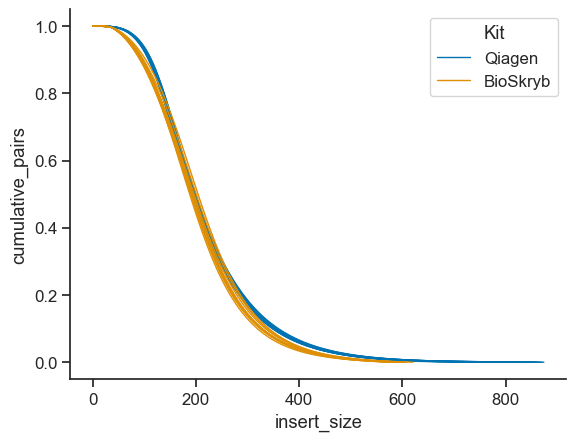

In [7]:
sns.lineplot(
    data=lens, #.query("Type == 'Single cell'"),
    x="insert_size",
    y="cumulative_pairs",
    hue="Kit",
    palette="colorblind",
    linewidth=1,
    units="NGI ID",
    estimator=None,
)

(0.0, 600.0)

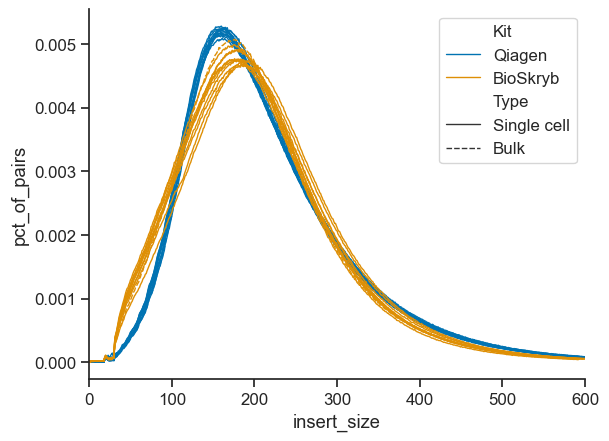

In [8]:
ax = sns.lineplot(
    data=lens, #.query("Type == 'Single cell'"),
    x="insert_size",
    y="pct_of_pairs",
    hue="Kit",
    palette="colorblind",
    style="Type",
    linewidth=1,
    units="NGI ID",
    estimator=None,
)
ax.set_xlim(0, 600)

## Chimeric reads 
translocations or pair spaced >100000 bp

In [9]:
chms = pd.read_csv("../analysis/downsample_40M/downstream/chimeric_reads/counts.txt", sep="\t")
chms["pct_chimeric"] = 100 * chms["chimeric_reads"] / chms["all_reads"]
chms["NGI ID"] = chms["sample"]
chms = chms.merge(samples, on="NGI ID")
chms["Kit_Type"] = chms["Kit"] + "_" + chms["Type"]
chms.head()

,sample,all_reads,chimeric_reads,pct_chimeric,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Kit_Type
0,P33410_1001,73461832,423030,0.575850,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,Qiagen_Single cell
1,P33410_1002,73788035,393670,0.533515,P33410_1002,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell,Qiagen_Single cell
2,P33410_1003,73804320,399565,0.541384,P33410_1003,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell,Qiagen_Single cell
3,P33410_1004,73422111,380224,0.517860,P33410_1004,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell,Qiagen_Single cell
4,P33410_1005,73772827,382804,0.518896,P33410_1005,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell,Qiagen_Single cell


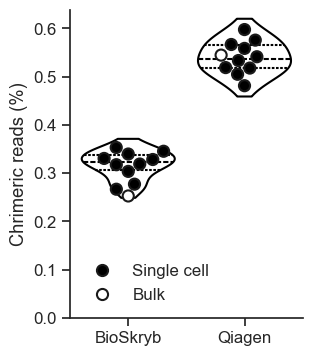

In [10]:
fig, ax = plt.subplots(figsize=(3, 4))
chms = chms.sort_values("Kit")
ax = sns.violinplot(
    data=chms.query("Type == 'Single cell'"), 
    x="Kit", 
    y="pct_chimeric", 
    inner="quart", 
    color="black",
    density_norm="width", 
    cut=1,
    fill=None, 
    zorder=-1,
    ax=ax,
)
ax = sns.swarmplot(
    data=chms, 
    x="Kit", 
    y="pct_chimeric", 
    hue="Type", 
    hue_order=["Single cell", "Bulk"],
    palette=["black", "white"],
    edgecolor="k",
    linewidth=1.5,
    size=8,
    ax=ax)
ax.set_ylim(bottom=0)
ax.set_ylabel("Chrimeric reads (%)")
ax.set_xlabel("")
plt.legend(frameon=False, framealpha=0, loc="lower left")
plt.savefig(figdir / "chimeric_reads.svg", bbox_inches="tight")

In [11]:
chms.groupby(["Kit", "Type"])["pct_chimeric"].mean().round(2)

Kit       Type       
BioSkryb  Bulk           0.25
          Single cell    0.32
Qiagen    Bulk           0.54
          Single cell    0.54
Name: pct_chimeric, dtype: float64